In [1]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pymatgen.core import Structure
from cdft.dft3d import dft_core
from cdft.lj_eos import lj_eos

torch.set_default_dtype(torch.float64)
device = torch.device('cuda')

plt.rcParams.update({'text.usetex':True, 
'font.family':'sans-serif', 
'font.size':18, 
'axes.linewidth':1.1,
'text.latex.preamble': r'\usepackage{sfmath}'
})

colors = sns.color_palette("mako")

In [2]:
sigma = 3.65
epsilon = 158.5
parameters = {'sigma':sigma, 'epsilon':epsilon}

In [3]:
structure = Structure.from_file('structures/IRMOF-1.cif')
print('formula:        ', structure.formula)
print('num_sites:      ', structure.num_sites)
print('lattice_lengths:', structure.lattice.lengths)

formula:         Zn32 H96 C192 O104
num_sites:       424
lattice_lengths: (25.832, 25.832, 25.832)


/home/lucas/miniforge3/envs/cdft/lib/python3.14/site-packages/pymatgen/io/cif.py:1817: UserWarning: Issues encountered while parsing CIF: Skipping relative stoichiometry check because CIF does not contain formula keys.
  return parser.parse_structures(primitive=primitive)[0]


In [4]:
T = 110.0
system_size = np.array([l for l in structure.lattice.lengths])
points = np.array([64, 64, 64])
dft = dft_core(parameters=parameters, temperature=T, system_size=system_size, angles=None, points=points, device=device)
dft.cell_size

array([0.403625, 0.403625, 0.403625])

In [5]:
forcefield = pd.DataFrame()
forcefield['type'] = ['C','H','O','Zn']
forcefield['sigma'] = np.array([3.473, 3.195, 3.033, 4.045])
forcefield['epsilon'] = np.array([47.8565, 7.6490, 48.1584, 27.6772])

def lj_potential(r,sigma,epsilon):
    return 4.0*epsilon*((sigma/r)**12-(sigma/r)**6)

rc = 12.0

Vext = torch.zeros_like(dft.X)
U = torch.zeros_like(dft.X)
for k, site in enumerate(structure):
    sigmas = float(forcefield['sigma'][forcefield['type']==site.species_string].values[0])
    epsilons = float(forcefield['epsilon'][forcefield['type']==site.species_string].values[0])
    sigmasf = 0.5*(sigma+sigmas)
    epsilonsf = np.sqrt(epsilon*epsilons)
    rx = dft.X-structure.cart_coords[k,0]
    ry = dft.Y-structure.cart_coords[k,1]
    rz = dft.Z-structure.cart_coords[k,2]
    rx -= system_size[0]*(rx/system_size[0]).round()
    ry -= system_size[1]*(ry/system_size[1]).round()
    rz -= system_size[2]*(rz/system_size[2]).round()
    r = torch.sqrt(rx**2+ry**2+rz**2)
    U = lj_potential(r,sigmasf,epsilonsf)
    U[r==0] = np.inf
    U[r>rc] = 0.0
    Vext += U

Text(0, 0.5, '$y$ (\\AA{})')

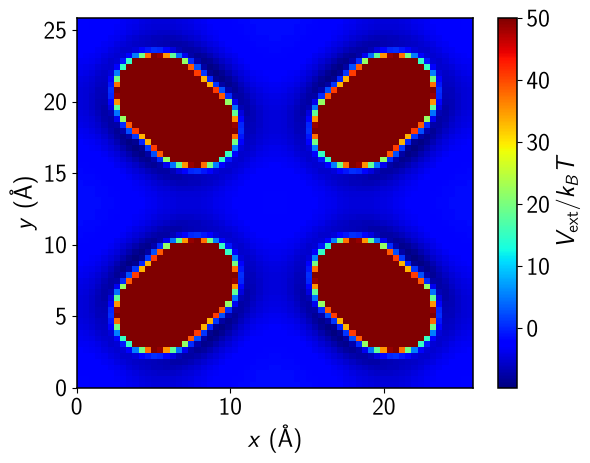

In [6]:
plt.figure()
c=plt.pcolormesh(dft.X[:,:,points[0]//2].cpu(),dft.Y[:,:,points[1]//2].cpu(),Vext[:,:,points[2]//2].cpu()/T,vmax=50.0,cmap='jet')
plt.colorbar(label=r'$V_{\mathrm{ext}}/k_B T$')
plt.xlabel(r'$x$ (\AA{})')
plt.ylabel(r'$y$ (\AA{})')

In [7]:
P = torch.hstack((torch.arange(1e0,1e1,1e0), torch.arange(1e1,1e2,1e1), torch.arange(1e2,1e3,1e1),
                  torch.arange(1e3,2e3,1e2)))
bulk_density = torch.empty_like(P)

eos = lj_eos(parameters, T)
bulk_density[0] = eos.density(P[0],'vap')
for i in range(1,len(P)):
    bulk_density[i] = eos.density(P[i],bulk_density[i-1])

In [8]:
NPRES = len(P)

ATTEMPTS = [
    dict(solver='fire', alpha0=0.2, dt=0.02, tol=1e-8, max_it=20000),
    dict(solver='fire', alpha0=0.2, dt=0.01, tol=1e-8, max_it=40000),
    dict(solver='fire', alpha0=0.1, dt=0.005, tol=1e-8, max_it=40000),
    dict(solver='picard', alpha0=0.02, tol=1e-8, max_it=50000),
]

def solve_point(dft, rhob, rho_guess, fmt='ASWB'):
    for kw in ATTEMPTS:
        if rho_guess is not None:
            dft.rho = rho_guess.clone()
        try:
            dft.equilibrium_density_profile(rhob, fmt=fmt, logoutput=False, **kw)
        except Exception:
            continue
        err = float(dft.error)
        if np.isfinite(err) and err <= kw['tol']:
            return True, err
    return False, float(dft.error)


def sweep(dft, order, rho_start):
    N = np.full(NPRES, np.nan)
    Om = np.full(NPRES, np.nan)
    ok = np.zeros(NPRES, dtype=bool)
    guess = rho_start
    last_good = rho_start
    for i in order:
        good, err = solve_point(dft, bulk_density[i], guess)
        ok[i] = good
        if good:
            N[i] = float(dft.total_molecules)
            Om[i] = float(dft.Omega)
            guess = dft.rho.detach().clone()
            print(dft.it,err,P[i].numpy(),N[i])
            last_good = guess
    return N, Om, ok, last_good

In [9]:
dft.initial_condition(bulk_density[0], Vext, potential_cutoff=50.)
Nads, Omega_ads, ok_a, _ = sweep(dft, range(NPRES), dft.rho.detach().clone())
Ndes, Omega_des, ok_d, _ = sweep(dft, range(NPRES-1, -1, -1), dft.rho.detach().clone())

173 3.6590886312184506e-09 1.0 0.1277363904443992
172 7.8090986542745e-09 2.0 0.2566543546428144
171 8.13271671827356e-09 3.0 0.38677530267514787
144 8.253893547538367e-09 4.0 0.5181213199960774
145 9.472587231601587e-09 5.0 0.6507151849342924
146 2.7721866226805284e-09 6.0 0.7845804095328279
146 7.336607525762953e-09 7.0 0.9197412267316579
146 1.56607138114561e-09 8.0 1.0562226827093488
119 2.1869992603180592e-09 9.0 1.1940505743143317
139 9.512480690432044e-09 10.0 1.333251543586469
172 7.60030051308593e-09 20.0 2.807277676449462
184 9.757409527025669e-09 30.0 4.454961484922132
198 8.486117209401081e-09 40.0 6.3197767656448764
201 9.503020324182313e-09 50.0 8.453213574265957
203 6.0249809295135055e-09 60.0 10.894542344113043
176 2.4533134535761106e-09 70.0 13.608816753209748
183 9.856526283778917e-09 80.0 16.40932451445283
194 9.383695930411683e-09 90.0 19.027051331670982
173 8.807199686857837e-09 100.0 21.309529527510445
167 9.26643046902606e-09 110.0 23.257003684353847
171 9.788329

In [14]:
both = ok_a & ok_d
scale = np.nanmax(np.abs(Omega_ads[both])) if both.any() else 1.0
atol = 1e-6*max(scale, 1.0)
distinct = both & (np.abs(Omega_des-Omega_ads) > atol)

Neq = Nads.copy()
take_des = distinct & (Omega_des < Omega_ads)
Neq[take_des] = Ndes[take_des]
only_des = (~ok_a) & ok_d
Neq[only_des] = Ndes[only_des]

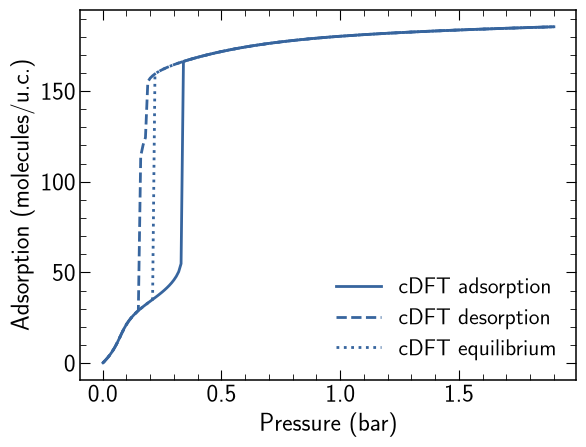

In [11]:
plt.plot(P*1e-3, Nads, '-', color=colors[2], lw=2.0, label='cDFT adsorption')
plt.plot(P*1e-3, Ndes, '--', color=colors[2], lw=2.0, label='cDFT desorption')
plt.plot(P*1e-3, Neq, ':', color=colors[2], lw=2.0, label='cDFT equilibrium')
plt.xlabel(r'Pressure (bar)', fontsize=18)
plt.ylabel(r'Adsorption (molecules/u.c.)', fontsize=18)
plt.minorticks_on()

plt.tick_params(direction='in',right=True, top=True)
plt.tick_params(labelsize=18)
plt.tick_params(labelbottom=True, labeltop=False, labelright=False, labelleft=True)
plt.tick_params(direction='in',which='minor', length=4, bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in',which='major', length=7, bottom=True, top=True, left=True, right=True)
plt.legend(fontsize=16, frameon=False, edgecolor='k')

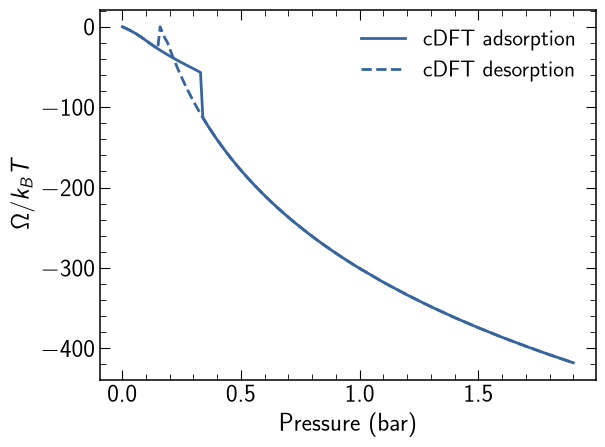

In [12]:
plt.plot(P*1e-3, Omega_ads, '-', color=colors[2], lw=2.0, label='cDFT adsorption')
plt.plot(P*1e-3, Omega_des, '--', color=colors[2], lw=2.0, label='cDFT desorption')
plt.xlabel(r'Pressure (bar)', fontsize=18)
plt.ylabel(r'$\Omega/k_B T$', fontsize=18)
plt.minorticks_on()

plt.tick_params(direction='in',right=True, top=True)
plt.tick_params(labelsize=18)
plt.tick_params(labelbottom=True, labeltop=False, labelright=False, labelleft=True)
plt.tick_params(direction='in',which='minor', length=4, bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in',which='major', length=7, bottom=True, top=True, left=True, right=True)
plt.legend(fontsize=16, frameon=False, edgecolor='k')